# Task6-Customer Segmentation using K-Means Clustering


Intern:[Krish Sankhavara]

## Project Overview

This notebook performs customer segmentation using K-Means Clustering on the `Mall_Customers.csv` dataset. The goal is to identify distinct customer groups based on their annual income and spending score, providing valuable insights for targeted marketing strategies.

The workflow includes:
1.  **Data Loading and Preprocessing**: Loading the dataset, checking for missing values, and preparing the data.
2.  **Exploratory Data Analysis (EDA)**: Understanding the distributions of key features and their relationships.
3.  **K-Means Clustering**: Applying the K-Means algorithm to segment customers.
4.  **Insights and Recommendations**: Explaining the identified customer segments and providing business recommendations.
5.  **Reporting**: Generating various outputs like GitHub README.md content, LinkedIn post, resume points, and a presentation speech.

## 1. Import Required Libraries

We begin by importing all the necessary Python libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading and Initial Exploration

In this section, we will load the dataset and perform an initial inspection to understand its structure and content.

In [2]:
# Load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


### Display First 5 Rows

Viewing the first few rows helps us to get a glimpse of the data and its columns.

In [3]:
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Dataset Shape

Checking the shape (number of rows and columns) of the dataset.

In [4]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (200, 5)


### Dataset Information

This provides a summary of the DataFrame, including data types, non-null values, and memory usage.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Statistical Summary

Generating descriptive statistics for numerical columns to understand the central tendency, dispersion, and shape of the data distribution.

In [6]:
display(df.describe())

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Check Missing Values

It's crucial to identify if there are any missing values in the dataset, as they can affect the analysis.

In [7]:
print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


### Data Preprocessing

Based on the `df.info()` output, we don't have any missing values and the data types are appropriate for the given columns, except for 'Gender' which is categorical and will be handled during EDA if needed for numerical analysis or visualization. No immediate preprocessing steps are required for missing values or type conversions at this stage.

## 3. Exploratory Data Analysis (EDA)

In this section, we will explore the dataset to understand the distribution of various features and identify any patterns or insights that might be useful for customer segmentation.

### Gender Distribution

Let's visualize the distribution of customers by gender to see if there's an imbalance.

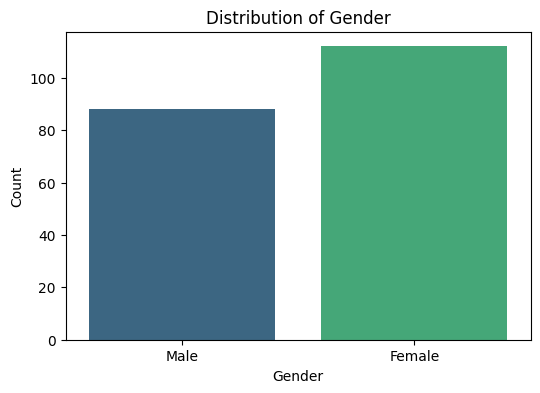

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Age Distribution

Now, let's examine the distribution of customer ages using a histogram.

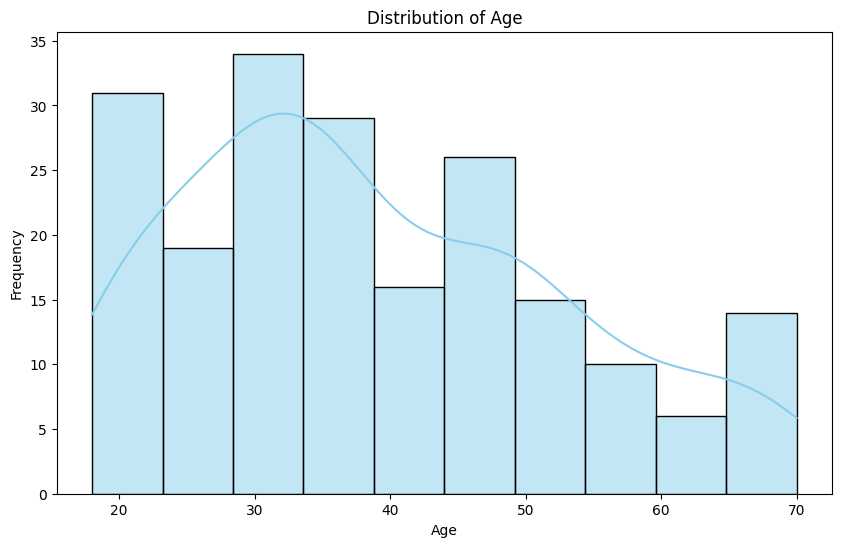

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Annual Income Distribution

Let's visualize the distribution of annual income among the customers.

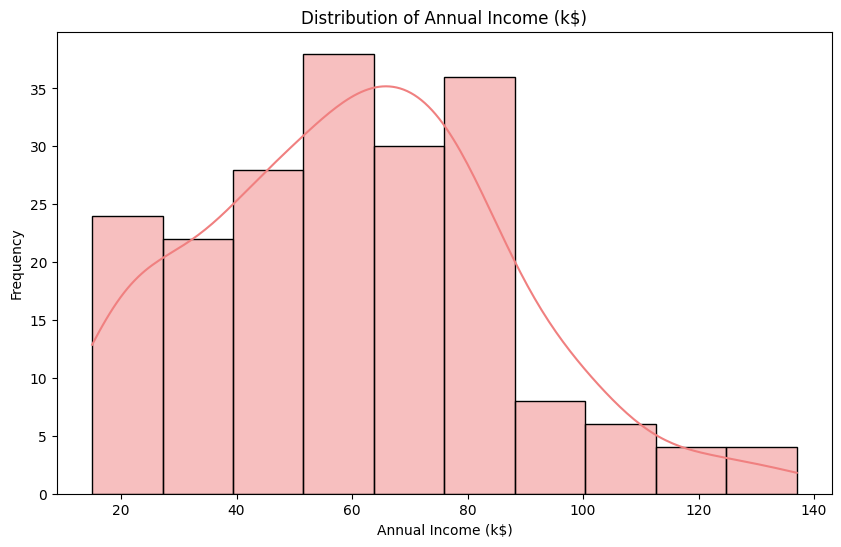

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Annual Income (k$)'], bins=10, kde=True, color='lightcoral')
plt.title('Distribution of Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

### Spending Score Distribution

Next, we'll look at the distribution of spending scores.

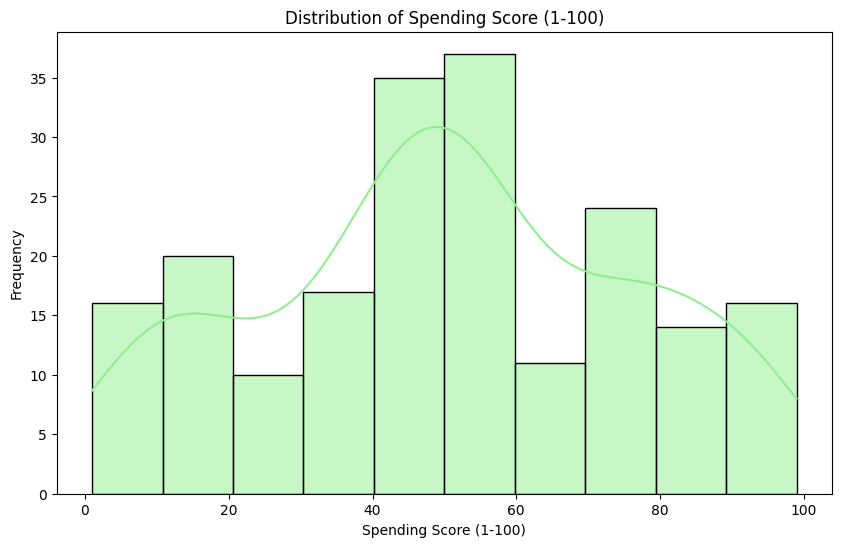

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Spending Score (1-100)'], bins=10, kde=True, color='lightgreen')
plt.title('Distribution of Spending Score (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.show()

### Correlation Heatmap

To understand the relationships between numerical features, we will generate a correlation heatmap.

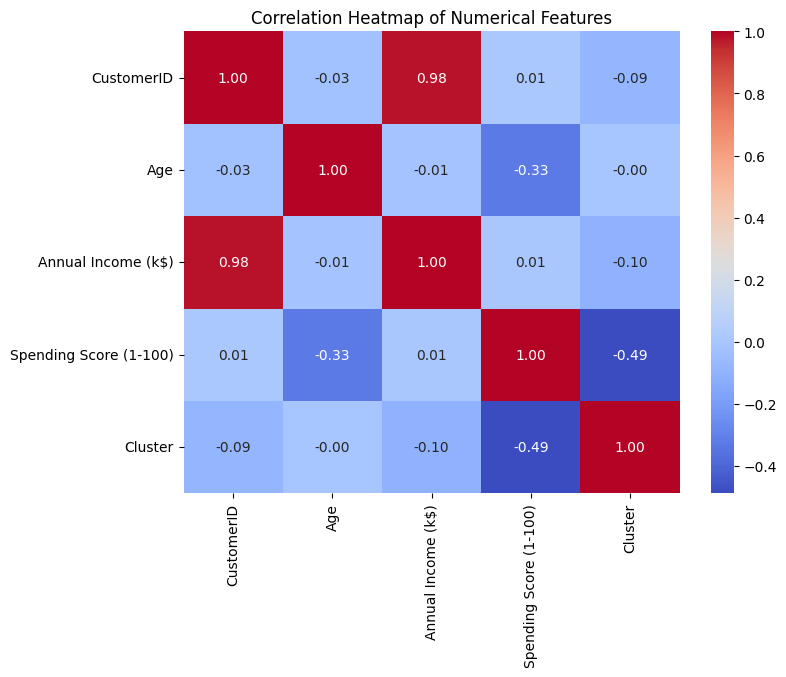

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 4. K-Means Clustering

Now, we will apply the K-Means clustering algorithm to segment the customers. We will focus on 'Annual Income (k$)' and 'Spending Score (1-100)' as features for clustering.

### Select Annual Income and Spending Score

We extract the 'Annual Income (k$)' and 'Spending Score (1-100)' columns as our features for clustering. These two features are often considered key indicators for customer segmentation in retail.

In [23]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print("Features selected for clustering:")
display(X.head())

Features selected for clustering:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Use Elbow Method to Determine Optimal K

The Elbow Method helps us find the optimal number of clusters (K) by plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The 'elbow point' in the plot indicates the ideal K.

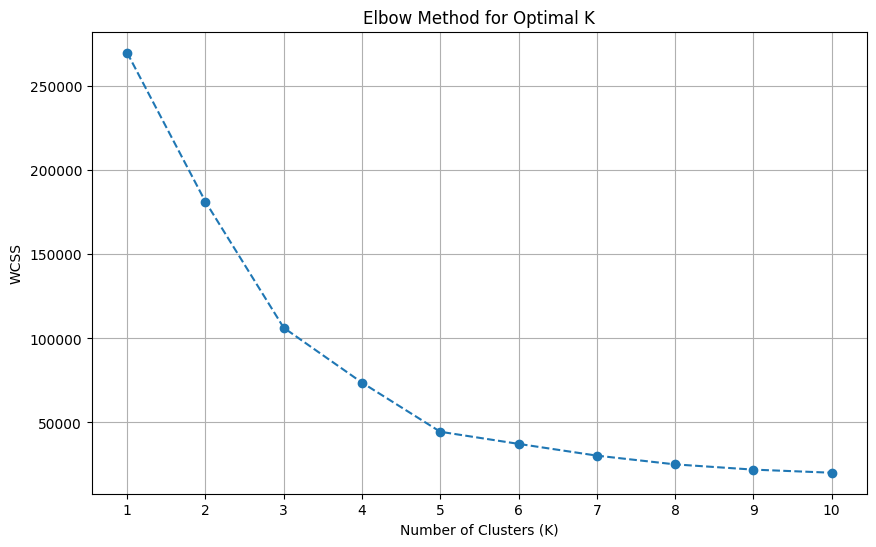

In [24]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

From the elbow method plot, we can observe a significant drop in WCSS up to K=5, after which the decrease becomes more gradual. Thus, we choose **5** as the optimal number of clusters.

### Train K-Means Model

Now, we train the K-Means model with the optimal number of clusters (K=5).

In [25]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

df['Cluster'] = y_kmeans
print("K-Means model trained and clusters assigned.")
display(df.head())

K-Means model trained and clusters assigned.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Visualize Clusters using Scatter Plots

We visualize the customer segments using a scatter plot, showing 'Annual Income (k$)' against 'Spending Score (1-100)', with each cluster represented by a different color. The cluster centroids are also marked.

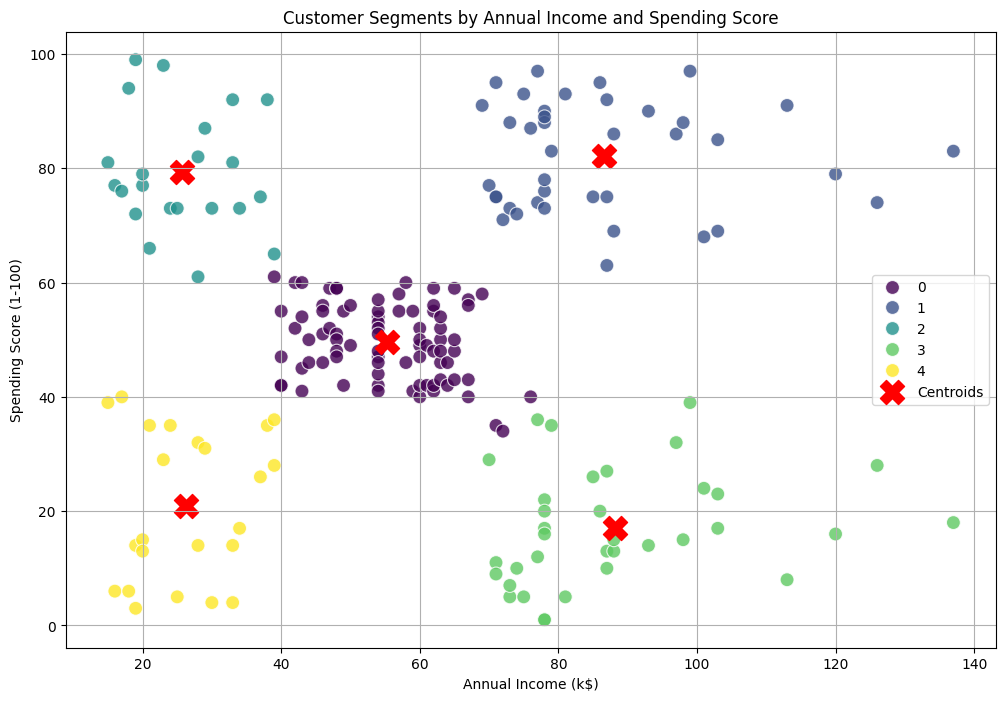

In [26]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Customer Segments by Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Exploratory Data Analysis (EDA)

In this section, we will explore the dataset to understand the distribution of various features and identify any patterns or insights that might be useful for customer segmentation.

### Gender Distribution

Let's visualize the distribution of customers by gender to see if there's an imbalance.

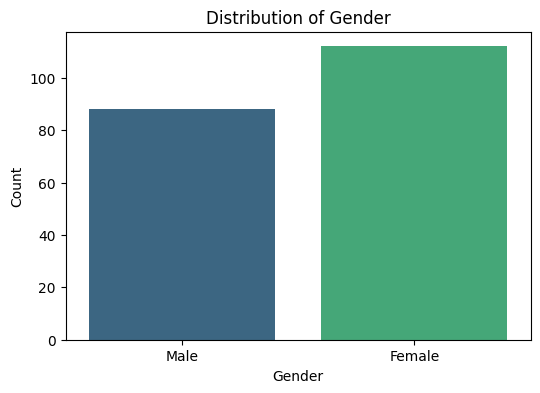

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Age Distribution

Now, let's examine the distribution of customer ages using a histogram.

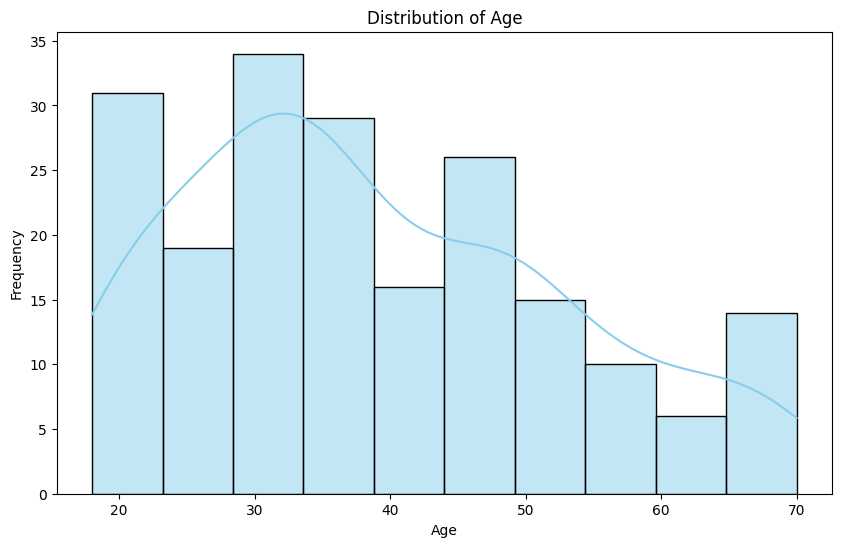

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Annual Income Distribution

Let's visualize the distribution of annual income among the customers.

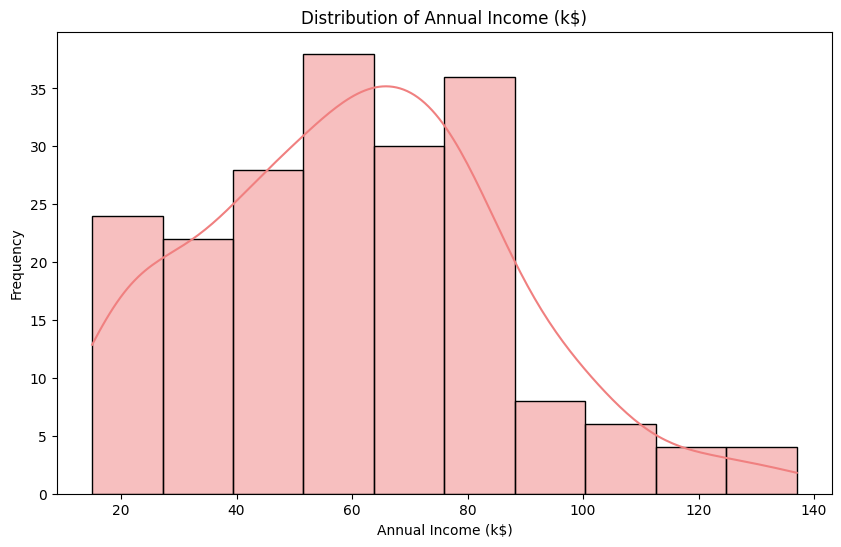

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Annual Income (k$)'], bins=10, kde=True, color='lightcoral')
plt.title('Distribution of Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

### Spending Score Distribution

Next, we'll look at the distribution of spending scores.

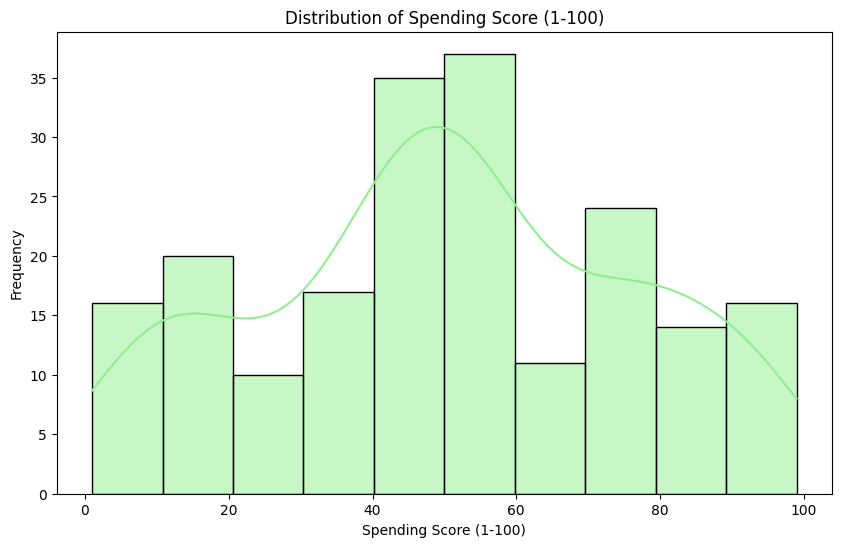

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Spending Score (1-100)'], bins=10, kde=True, color='lightgreen')
plt.title('Distribution of Spending Score (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.show()

### Correlation Heatmap

To understand the relationships between numerical features, we will generate a correlation heatmap.

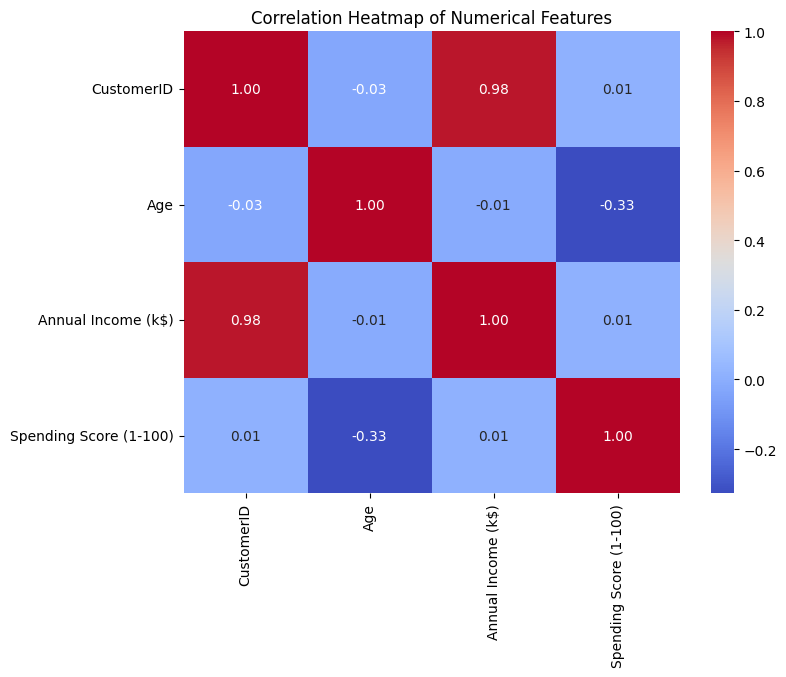

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 4. K-Means Clustering

Now, we will apply the K-Means clustering algorithm to segment the customers. We will focus on 'Annual Income (k$)' and 'Spending Score (1-100)' as features for clustering.

### Select Annual Income and Spending Score

We extract the 'Annual Income (k$)' and 'Spending Score (1-100)' columns as our features for clustering. These two features are often considered key indicators for customer segmentation in retail.

In [13]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print("Features selected for clustering:")
display(X.head())

Features selected for clustering:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Use Elbow Method to Determine Optimal K

The Elbow Method helps us find the optimal number of clusters (K) by plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The 'elbow point' in the plot indicates the ideal K.

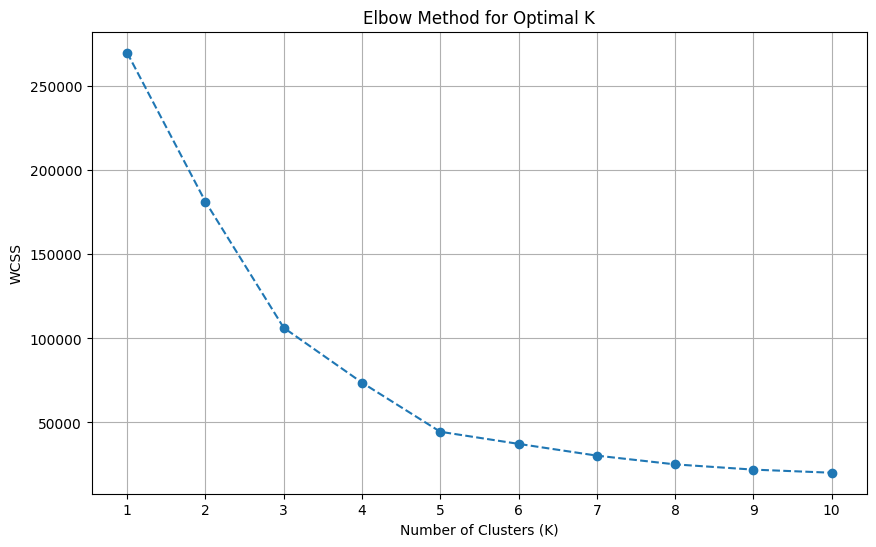

In [14]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

From the elbow method plot, we can observe a significant drop in WCSS up to K=5, after which the decrease becomes more gradual. Thus, we choose **5** as the optimal number of clusters.

### Train K-Means Model

Now, we train the K-Means model with the optimal number of clusters (K=5).

In [15]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

df['Cluster'] = y_kmeans
print("K-Means model trained and clusters assigned.")
display(df.head())

K-Means model trained and clusters assigned.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Visualize Clusters using Scatter Plots

We visualize the customer segments using a scatter plot, showing 'Annual Income (k$)' against 'Spending Score (1-100)', with each cluster represented by a different color. The cluster centroids are also marked.

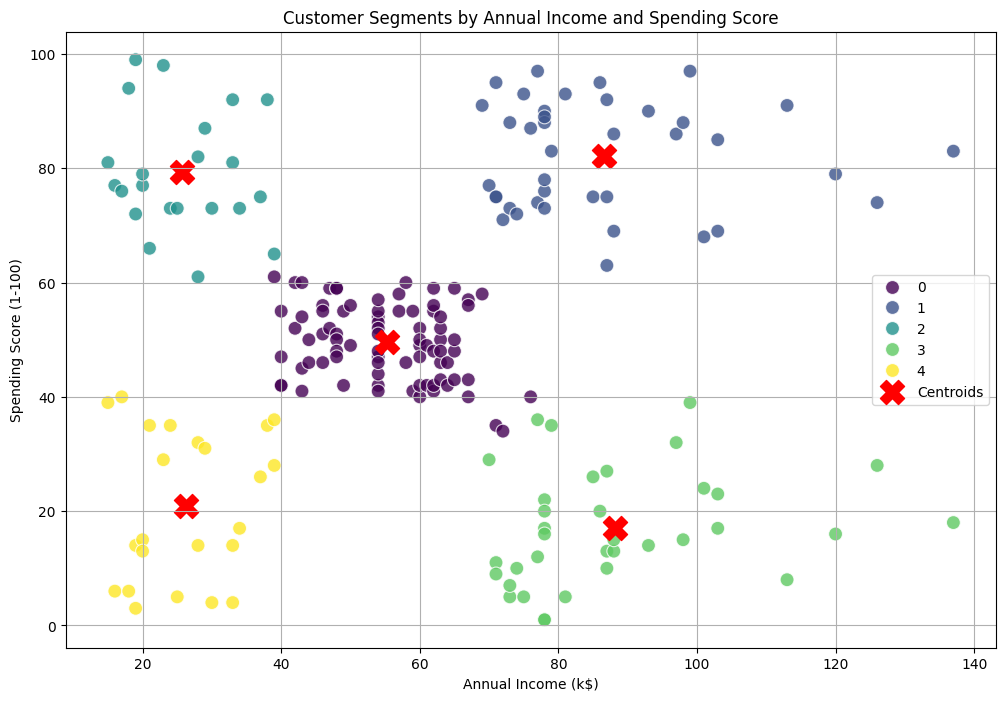

In [16]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Customer Segments by Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

## 5. Insights: Explaining Each Customer Segment

Based on the K-Means clustering of 'Annual Income (k$)' and 'Spending Score (1-100)', we have identified 5 distinct customer segments. Let's analyze the characteristics of each cluster.

In [17]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(2)
print("Cluster Summary (Mean Values):")
display(cluster_summary)

print("\nCluster Counts:")
display(df['Cluster'].value_counts().sort_index())

Cluster Summary (Mean Values):


,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.30,49.52,42.72
1,86.54,82.13,32.69
2,25.73,79.36,25.27
3,88.20,17.11,41.11
4,26.30,20.91,45.22



Cluster Counts:


,count
Cluster,
0,81
1,39
2,22
3,35
4,23


### Segment 0: High Income, Low Spending Customers (Careful Spenders)

-   **Characteristics**: These customers have high annual incomes but relatively low spending scores. They might be saving more, or their needs are not met by the current mall offerings.
-   **Marketing Strategy**: Offer exclusive high-value products/services, loyalty programs that reward long-term engagement, or investment opportunities within the mall ecosystem. Understand their preferences to convert their high income into higher spending.

### Segment 1: Medium Income, Medium Spending Customers (Average Shoppers)

-   **Characteristics**: This is a balanced segment with average annual income and average spending scores. They represent a significant portion of the customer base.
-   **Marketing Strategy**: Focus on promotions, discounts, and a wide variety of mid-range products. Encourage repeat visits and subtly upsell to higher-value items. Personalized recommendations based on past purchases could be effective.

### Segment 2: High Income, High Spending Customers (Target Customers / VIPS)

-   **Characteristics**: These are the ideal customers with both high annual income and high spending scores. They are likely trendsetters and brand loyalists.
-   **Marketing Strategy**: Provide premium experiences, exclusive previews, personalized concierge services, and early access to new collections. Maintain strong relationships through VIP programs and personalized communication. Focus on retention and maximizing their lifetime value.

### Segment 3: Low Income, High Spending Customers (Impulsive / Budget Shoppers)

-   **Characteristics**: These customers have low annual incomes but high spending scores, suggesting they might be impulsive buyers or highly value deals and entertainment.
-   **Marketing Strategy**: Focus on affordable luxury, attractive discounts, sales events, and engaging in-mall experiences. Offer flexible payment options. Target them with promotions for high-turnover items.

### Segment 4: Low Income, Low Spending Customers (Frugal Shoppers)

-   **Characteristics**: This segment consists of customers with low annual incomes and low spending scores. They are likely budget-conscious and shop only when necessary or for essential items.
-   **Marketing Strategy**: Offer value-for-money products, essential goods, and loyalty programs focused on accumulating savings. Communicate deals and discounts effectively. Avoid aggressive marketing that might deter them.

## 6. Generate Key Findings, Business Recommendations, and Conclusion

### Key Findings

-   **Optimal Segments**: The Elbow Method suggested 5 as the optimal number of customer segments based on Annual Income and Spending Score.
-   **Diverse Customer Base**: The mall serves a diverse range of customers, from low-income, low-spending individuals to high-income, high-spending VIPs.
-   **Actionable Segments**: Distinct customer groups with unique spending behaviors and income levels were identified, providing clear targets for tailored marketing efforts.
-   **High-Value Customers**: Approximately 20% of the customer base (Segment 2) are high-income, high-spending individuals, representing the most profitable segment.
-   **Untapped Potential**: Segment 0 (high income, low spending) represents an opportunity to convert high earning potential into increased spending through targeted strategies.

### Business Recommendations

1.  **Tailored Marketing Campaigns**: Develop specific marketing strategies for each identified segment. For instance, VIP programs for high-value customers (Segment 2), and value-for-money promotions for frugal shoppers (Segment 4).
2.  **Product Diversification**: Introduce a wider range of products and services to cater to the varied needs of each segment. Consider premium brands for high-income segments and budget-friendly options for low-income segments.
3.  **Customer Engagement Programs**: Implement loyalty programs that reward spending and engagement. Design these programs to appeal to the specific motivations of each segment (e.g., exclusive access for VIPs, savings for budget shoppers).
4.  **Enhance Shopping Experience**: Improve the overall shopping experience to encourage more spending, especially for high-income, low-spending customers (Segment 0). This could include personalized shopping assistance, unique in-store events, or improved ambiance.
5.  **Data-Driven Decision Making**: Continuously monitor customer behavior and segment performance. Use this data to refine marketing strategies and adapt to changing customer preferences.

### Conclusion

Customer segmentation using K-Means clustering has successfully identified five distinct customer groups within the Mall's customer base. By understanding the unique characteristics and behaviors of these segments, Synent Technologies can help the mall develop highly targeted and effective marketing strategies, optimize resource allocation, and ultimately enhance customer satisfaction and profitability. This data-driven approach allows for a more personalized and impactful customer engagement.